# Phase 4 — WR Model: Tuned XGBoost with Walk-Forward Optuna Search

Trained only on WR's Phase 3-selected 8 features: `scarcity_z`, `wopr`, `vorp_delta_yoy`, `receiving_epa`, `air_yards_share`, `age`, `draft_pick_inverse`, `target_share`. Structured identically to `06a_model_qb.ipynb` / `06b_model_rb.ipynb`, but with two lessons already applied from the start instead of discovered partway through:

1. **`max_depth` search range is 2-8 from the first run**, not 2-4. QB's and RB's notebooks both had to walk this back after `05b_qb_feature_experiment.ipynb` found the narrower range was an artificial cap — confirmed a real, if position-specific, win for both. No reason to repeat that mistake a third time; WR's own folds get the wider range immediately and decide for themselves whether it helps.
2. **The `low_confidence_extreme_delta` flag and its underlying delta-bucket diagnostic are built in from the start**, not bolted on after a live-prediction sanity check went sideways (which is how QB found it via `05b`, Sections 8-9). `vorp_delta_yoy`'s extreme-tail weakness is now confirmed at two independent positions (QB, RB) — this notebook checks directly, immediately, whether WR shows the same pattern, rather than assuming it does or doesn't.

Everything else — monotonic constraints checked per feature rather than assumed, the unconstrained-vs-constrained diagnostic, the naive baseline comparison, median-hyperparameter final model — follows the same standing methodology as every prior position notebook.

In [1]:
from datetime import datetime

print(f"Results as of {datetime.now().astimezone():%Y-%m-%d %H:%M %Z}, pulling live nflreadpy data -- "
      "rerunning this notebook will reflect any upstream corrections made to that data since.")

Results as of 2026-09-16 13:27 Central Daylight Time, pulling live nflreadpy data -- rerunning this notebook will reflect any upstream corrections made to that data since.


## Setup: load `features_df` and build WR's target rows

All 8 selected features are available directly as columns on `vorp_labels.parquet` (`receiving_epa`, `target_share`, `air_yards_share`, `wopr` come straight from nflreadpy's seasonal stats, no play-by-play or team-stats pull needed) or built the same way every other position has built them (`scarcity_z`, `vorp_delta_yoy`, `age`, `draft_pick_inverse`). No Phase 3 full-pipeline rebuild required, matching RB's notebook's approach.

In [2]:
import sys
from pathlib import Path

import nflreadpy as nfl
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "wopr", "vorp_delta_yoy", "receiving_epa", "air_yards_share", "age", "draft_pick_inverse", "target_share"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
wr = vorp_labels[vorp_labels["position"] == "WR"][
    ["season", "player_id", "player_display_name", "vorp", "vorp_next",
     "wopr", "receiving_epa", "air_yards_share", "target_share"]
].copy()

# scarcity_z (within-position, within-season standardization -- same recipe as Phase 3)
season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
wr_stats = season_position_stats[season_position_stats["position"] == "WR"]
wr = wr.merge(wr_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
wr["scarcity_z"] = (wr["vorp"] - wr["position_mean_vorp"]) / wr["position_std_vorp_that_season"]
wr = wr.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

# vorp_delta_yoy
prior = wr[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
wr = wr.merge(prior, on=["player_id", "season"], how="left")
wr["vorp_delta_yoy"] = wr["vorp"] - wr["vorp_last_season"]
wr = wr.drop(columns=["vorp_last_season"])

# age, draft_pick_inverse
players = nfl.load_players().to_pandas()
wr = wr.merge(players[["gsis_id", "birth_date", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
wr["birth_date"] = pd.to_datetime(wr["birth_date"])
season_start = pd.to_datetime(wr["season"].astype(str) + "-09-01")
wr["age"] = (season_start - wr["birth_date"]).dt.days / 365.25
wr["draft_pick_inverse"] = 1 / wr["draft_pick"]
wr = wr.drop(columns=["gsis_id", "birth_date", "draft_pick"])

# Keep 2025's rows before dropping them below -- their vorp_next is 2026's outcome, which
# doesn't exist yet, so dropna() would discard them. Needed later for the live 2026 inference section.
wr_2025_features = wr[wr["season"] == 2025].copy()

wr = wr.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"WR rows with a usable label: {len(wr)}, seasons {wr['season'].min()}-{wr['season'].max()}")
print(wr[FEATURES].isna().mean().rename("null_rate"))

C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WR rows with a usable label: 2731, seasons 2008-2024
scarcity_z            0.000000
wopr                  0.031124
vorp_delta_yoy        0.293665
receiving_epa         0.038814
air_yards_share       0.000000
age                   0.000000
draft_pick_inverse    0.261443
target_share          0.031124
Name: null_rate, dtype: float64


## Walk-forward folds (same structure as `05_feature_selection.ipynb` / `06a_model_qb.ipynb` / `06b_model_rb.ipynb`)

In [3]:
MIN_TRAIN_SEASONS = 9


def make_walk_forward_folds(df, min_train_seasons=MIN_TRAIN_SEASONS):
    seasons_sorted = sorted(df["season"].unique())
    folds = []
    for i in range(min_train_seasons, len(seasons_sorted)):
        train_seasons = sorted(seasons_sorted[:i])
        test_season = seasons_sorted[i]
        train_idx = df.index[df["season"].isin(train_seasons)].to_numpy()
        test_idx = df.index[df["season"] == test_season].to_numpy()
        if len(train_idx) > 0 and len(test_idx) > 0:
            folds.append((train_idx, test_idx, test_season, train_seasons))
    return folds


folds = make_walk_forward_folds(wr)
print(f"{len(folds)} walk-forward folds, test seasons: {[f[2] for f in folds]}")

8 walk-forward folds, test seasons: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Monotonic constraints: checked per feature, not assumed

Each of WR's 8 features checked individually for whether it has an unambiguous, confound-free "more is better/worse" relationship with next-season value — same standard QB and RB were held to, extended to a larger feature set:

| Feature | Constraint | Reasoning |
|---|---|---|
| `scarcity_z` | **+1** | Standing further above the field *this* season should never predict a *worse* expected standing next season, all else equal. Unambiguous — same reasoning as every prior position. |
| `wopr` | **+1** | A direct, designed-for-this opportunity metric (weighted combination of target share and air yards share) — no realistic mechanism where commanding *more* of a team's passing-game opportunity this season predicts *lower* value next season, holding the other features fixed. |
| `vorp_delta_yoy` | **+1** | An improving trajectory is more plausible to continue than to reverse, especially once `scarcity_z` already anchors the current level. Same reasoning as QB and RB. |
| `receiving_epa` | **+1** | A direct efficiency metric, same reasoning QB's notebook applied to `passing_epa` — no realistic mechanism where being *more* efficient this season predicts *lower* value next season, all else fixed. |
| `air_yards_share` | **+1** | Same opportunity-metric logic as `wopr` — a larger share of the team's downfield volume this season is not a plausible predictor of *lower* value next season, holding the rest of the feature set fixed. |
| `target_share` | **+1** | Same reasoning as `wopr`/`air_yards_share` — direct opportunity, not ambiguous. |
| `age` | **0 (none)** | Explicitly NOT monotonic — fantasy production rises then falls with age, same career-arc reasoning as every prior position. Forcing a single direction here would contradict the real shape of that curve. |
| `draft_pick_inverse` | **0 (none)** | Same real ambiguity as QB and RB: a fixed pre-career proxy for opportunity/organizational investment, not a performance metric. Conditional on the other 7 features already carrying realized performance and opportunity, it isn't clean enough to force a direction. Left unconstrained rather than guessed. |

**6 of 8 features get a constraint** (`scarcity_z`, `wopr`, `vorp_delta_yoy`, `receiving_epa`, `air_yards_share`, `target_share`, all `+1`); `age` and `draft_pick_inverse` are left free — a higher constrained share than QB (3/6) or RB (2/4), simply because WR's selected feature set has more direct performance/opportunity metrics and fewer ambiguous proxies. Whether constraining actually helps is checked directly below, not assumed from the reasoning alone.

In [4]:
MONOTONE_CONSTRAINTS = (1, 1, 1, 1, 1, 0, 0, 1)  # matches FEATURES order exactly
print(dict(zip(FEATURES, MONOTONE_CONSTRAINTS)))

{'scarcity_z': 1, 'wopr': 1, 'vorp_delta_yoy': 1, 'receiving_epa': 1, 'air_yards_share': 1, 'age': 0, 'draft_pick_inverse': 0, 'target_share': 1}


## Per-fold Optuna search (TPE sampler, pruning enabled)

For each outer walk-forward fold, the search space is `max_depth` (2-8, wide from the start — QB and RB both confirmed the previously-assumed 2-4 cap was artificial, so there is no reason to re-litigate that here), `min_child_weight` (1-10), `reg_lambda` (log-scale 0.1-10), `learning_rate` (log-scale 0.01-0.3), `subsample` (0.6-1.0). `n_estimators` is never tuned directly — each trial uses early stopping (up to 500 rounds, 20-round patience) to find its own iteration count.

**The search never touches the outer fold's held-out test season.** Within each outer fold's own training window, the *most recent* training season is carved out as an inner validation split (everything before it is inner-train) — Optuna's objective is scored purely on that inner split. Real mid-training pruning is wired in via a custom `xgboost.callback.TrainingCallback` that reports each boosting round's validation MAE back to Optuna's `MedianPruner`, not just a pass/fail after the fact.

Once a fold's best hyperparameters and iteration count are found (from the inner split alone), the model is refit on the *entire* outer-fold training window before being scored on the real, still-untouched held-out test season.

**Interface**: `XGBRegressor`-first, matching QB/RB's shared interface — `XGBRegressor(..., callbacks=[OptunaPruningCallback(trial)]).fit(X_train, y_train, eval_set=[(X_valid, y_valid)])`, not `xgb.train()`/`DMatrix`.

**Out-of-fold predictions are also collected here**, alongside each row's `vorp_delta_yoy` and `scarcity_z` — needed for the delta-bucket diagnostic later in this notebook. This is the one structural difference from QB/RB's original `run_all_folds`: those two notebooks only kept aggregated fold metrics and had to reconstruct individual predictions after the fact when the diagnostic need came up. WR's version collects them the first time through.

In [5]:
N_TRIALS = 40


class OptunaPruningCallback(xgb.callback.TrainingCallback):
    """Reports each boosting round's validation MAE back to Optuna so its
    pruner can stop a clearly-unpromising trial mid-training, not just
    compare finished trials against each other after the fact.

    Reads "validation_0" -- XGBRegressor's auto-generated eval_set name --
    not the "valid" key the native xgb.train(evals=[...]) API would use."""

    def __init__(self, trial):
        self.trial = trial

    def after_iteration(self, model, epoch, evals_log):
        score = evals_log["validation_0"]["mae"][-1]
        self.trial.report(score, step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned()
        return False


def run_optuna_for_fold(df, train_idx, monotone_constraints, n_trials=N_TRIALS, seed=42):
    train_seasons_sorted = sorted(df.loc[train_idx, "season"].unique())
    inner_valid_season = train_seasons_sorted[-1]
    inner_train_seasons = train_seasons_sorted[:-1]
    inner_train_idx = df.index[df["season"].isin(inner_train_seasons) & df.index.isin(train_idx)]
    inner_valid_idx = df.index[(df["season"] == inner_valid_season) & df.index.isin(train_idx)]

    X_train = df.loc[inner_train_idx, FEATURES]
    y_train = df.loc[inner_train_idx, "vorp_next"]
    X_valid = df.loc[inner_valid_idx, FEATURES]
    y_valid = df.loc[inner_valid_idx, "vorp_next"]

    def objective(trial):
        params = {
            "objective": "reg:squarederror", "eval_metric": "mae",
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10, log=True),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "monotone_constraints": monotone_constraints, "seed": seed,
            "n_estimators": 500, "early_stopping_rounds": 20,
            "callbacks": [OptunaPruningCallback(trial)],
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        trial.set_user_attr("best_iteration", model.best_iteration)
        return model.best_score

    study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def fold_gain_share(model):
    """Gain importance for one fold's refit booster, normalized to shares
    over FEATURES (0 for any feature the booster never split on) -- same
    definition Phase 3 used (mean gain share across walk-forward folds)."""
    scores = model.get_booster().get_score(importance_type="gain")
    raw = np.array([scores.get(f, 0.0) for f in FEATURES])
    total = raw.sum()
    return raw / total if total > 0 else raw


def run_all_folds(df, folds, monotone_constraints, label):
    fold_results, fold_best_params, fold_gain_shares, oof_rows = [], [], [], []
    for tr, te, test_season, train_seasons in folds:
        study = run_optuna_for_fold(df, tr, monotone_constraints)
        best_params = dict(study.best_params)
        best_iteration = study.best_trial.user_attrs["best_iteration"]

        X_train_full = df.loc[tr, FEATURES]
        y_train_full = df.loc[tr, "vorp_next"]
        X_test = df.loc[te, FEATURES]
        final_model = xgb.XGBRegressor(
            objective="reg:squarederror", monotone_constraints=monotone_constraints, seed=42,
            n_estimators=max(best_iteration, 1), **best_params,
        )
        final_model.fit(X_train_full, y_train_full)
        preds = final_model.predict(X_test)
        actual = df.loc[te, "vorp_next"]

        mae = mean_absolute_error(actual, preds)
        rmse = mean_squared_error(actual, preds) ** 0.5
        rho = spearmanr(actual, preds)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan

        fold_results.append({"position": "WR", "test_season": test_season, "n_test": len(te), "mae": mae, "rmse": rmse, "spearman": rho})
        fold_best_params.append(best_params | {"n_estimators": best_iteration})
        fold_gain_shares.append(fold_gain_share(final_model))
        oof_rows.append(pd.DataFrame({
            "test_season": test_season,
            "predicted_vorp_next": preds,
            "actual_vorp_next": actual.to_numpy(),
            "vorp_delta_yoy": df.loc[te, "vorp_delta_yoy"].to_numpy(),
            "scarcity_z": df.loc[te, "scarcity_z"].to_numpy(),
        }))

    fold_df = pd.DataFrame(fold_results)
    mean_gain_df = pd.DataFrame({"feature": FEATURES, "mean_gain_share": np.mean(fold_gain_shares, axis=0)})
    oof_df = pd.concat(oof_rows, ignore_index=True)
    print(f"[{label}] Mean MAE: {fold_df['mae'].mean():.2f}, Mean RMSE: {fold_df['rmse'].mean():.2f}, Mean Spearman: {fold_df['spearman'].mean():.3f}")
    return fold_df, pd.DataFrame(fold_best_params), mean_gain_df, oof_df


fold_metrics_constrained_df, fold_params_constrained_df, gain_constrained_df, oof_constrained_df = run_all_folds(wr, folds, MONOTONE_CONSTRAINTS, label="tuned + monotonic")
print(fold_metrics_constrained_df.to_string(index=False))

[tuned + monotonic] Mean MAE: 37.42, Mean RMSE: 48.97, Mean Spearman: 0.733
position  test_season  n_test       mae      rmse  spearman
      WR         2017     159 40.173810 50.871756  0.725593
      WR         2018     159 37.965312 50.875228  0.720010
      WR         2019     169 39.761007 51.110927  0.696751
      WR         2020     187 37.011324 52.581040  0.674393
      WR         2021     186 33.083705 42.003785  0.749635
      WR         2022     167 34.011319 43.146486  0.784655
      WR         2023     173 44.240962 53.558982  0.735135
      WR         2024     178 33.081551 47.613435  0.775882


## Diagnostic: does the monotonic constraint actually help?

Domain reasoning alone doesn't guarantee a constraint helps a small dataset — checked directly rather than assumed, same as every position before this one.

In [6]:
NO_CONSTRAINTS = (0, 0, 0, 0, 0, 0, 0, 0)
fold_metrics_unconstrained_df, fold_params_unconstrained_df, gain_unconstrained_df, oof_unconstrained_df = run_all_folds(wr, folds, NO_CONSTRAINTS, label="tuned, no constraints")

[tuned, no constraints] Mean MAE: 37.20, Mean RMSE: 47.64, Mean Spearman: 0.742


**Finding, reported honestly**: unconstrained wins clearly on **both** metrics — MAE 37.20 vs. 37.42 constrained (a real, if modest, ~0.6% difference), and Spearman 0.742 vs. 0.733 constrained (+0.009). Unlike RB (where constraining 2 features won cleanly) and closer to QB's own result (where dropping constraints won outright on both metrics), **WR sides with QB**: despite 6 of 8 features having a defensible directional argument, forcing that many constraints on a dataset this size costs more flexibility than it buys in bias reduction. Per the project's standing decision rule (a model that wins on both MAE and Spearman replaces the alternative), **the unconstrained model is official for WR** — every result below this point (final model, fold metrics, delta-bucket diagnostic) uses the unconstrained run.

This is a real, position-specific result, not a coin flip inherited from QB: RB's own notebook found the opposite answer on its own held-out folds using the identical methodology, so there was no way to predict WR's outcome in advance from either QB's or RB's alone.

### `age` vs `draft_pick_inverse`: the two features left unconstrained, actual gain values not just rank

Same comparison QB and RB ran for their own free features, using the same methodology as Phase 3 (mean gain share across the walk-forward folds' own refit models, not a single all-data model).

In [7]:
# Phase 3's original untuned mean gain shares (05_feature_selection.ipynb), for the same 2 features.
phase3_gain = {"draft_pick_inverse": 0.032876, "age": 0.031461}

focus = ["draft_pick_inverse", "age"]
rows = []
for f in focus:
    constrained_val = gain_constrained_df.set_index("feature").loc[f, "mean_gain_share"]
    unconstrained_val = gain_unconstrained_df.set_index("feature").loc[f, "mean_gain_share"]
    rows.append({
        "feature": f,
        "phase3_untuned": phase3_gain[f],
        "phase4_tuned_constrained": constrained_val,
        "phase4_tuned_unconstrained": unconstrained_val,
    })
focus_df = pd.DataFrame(rows)
print(focus_df.to_string(index=False))

print("\nGap (draft_pick_inverse - age), each run:")
for col in ["phase3_untuned", "phase4_tuned_constrained", "phase4_tuned_unconstrained"]:
    gap = focus_df.set_index("feature").loc["draft_pick_inverse", col] - focus_df.set_index("feature").loc["age", col]
    ratio = focus_df.set_index("feature").loc["draft_pick_inverse", col] / focus_df.set_index("feature").loc["age", col]
    print(f"  {col}: gap={gap:+.4f}, draft_pick_inverse is {ratio:.2f}x age")

print("\nFull gain tables (all 8 features), for context:")
print("\nConstrained (diagnostic only, not shipped):")
print(gain_constrained_df.sort_values("mean_gain_share", ascending=False).to_string(index=False))
print("\nUnconstrained (Phase 4 official):")
print(gain_unconstrained_df.sort_values("mean_gain_share", ascending=False).to_string(index=False))

           feature  phase3_untuned  phase4_tuned_constrained  phase4_tuned_unconstrained
draft_pick_inverse        0.032876                  0.041325                    0.053137
               age        0.031461                  0.036662                    0.057194

Gap (draft_pick_inverse - age), each run:
  phase3_untuned: gap=+0.0014, draft_pick_inverse is 1.04x age
  phase4_tuned_constrained: gap=+0.0047, draft_pick_inverse is 1.13x age
  phase4_tuned_unconstrained: gap=-0.0041, draft_pick_inverse is 0.93x age

Full gain tables (all 8 features), for context:

Constrained (diagnostic only, not shipped):
           feature  mean_gain_share
        scarcity_z         0.682985
              wopr         0.084198
      target_share         0.066194
draft_pick_inverse         0.041325
               age         0.036662
     receiving_epa         0.034454
   air_yards_share         0.034008
    vorp_delta_yoy         0.020175

Unconstrained (Phase 4 official):
           feature  mean_g

**Finding**: `draft_pick_inverse` outranks `age` in Phase 3's untuned chart (0.0329 vs. 0.0315) and still does under WR's own constrained diagnostic (0.0413 vs. 0.0367) — but **the ranking flips under the official unconstrained model** (`age` 0.0572 vs. `draft_pick_inverse` 0.0531). This is the same kind of ranking instability QB's notebook found under its own wider search (where `passing_epa` overtook `draft_pick_inverse`) — a real, if secondary, finding rather than noise to smooth over. Both features stay well behind `scarcity_z`, `wopr`, and `target_share` regardless of which run is inspected, so this flip doesn't change any football-sense red flags, but it's honest to note that this specific ranking is not stable across constraint choices for WR either.

## Naive baseline, same folds — apples-to-apples with Phase 3

In [8]:
naive_records = []
for tr, te, test_season, train_seasons in folds:
    actual = wr.loc[te, "vorp_next"]
    naive_pred = wr.loc[te, "vorp"]
    mae = mean_absolute_error(actual, naive_pred)
    rho = spearmanr(actual, naive_pred)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan
    naive_records.append({"test_season": test_season, "mae": mae, "spearman": rho})
naive_df = pd.DataFrame(naive_records)
naive_mae, naive_spearman = naive_df["mae"].mean(), naive_df["spearman"].mean()
print(f"Naive baseline -- Mean MAE: {naive_mae:.2f}, Mean Spearman: {naive_spearman:.3f}")

Naive baseline -- Mean MAE: 39.34, Mean Spearman: 0.730


## Did tuning meaningfully close the gap Phase 3 found?

In [9]:
tuned_mae, tuned_spearman = fold_metrics_unconstrained_df["mae"].mean(), fold_metrics_unconstrained_df["spearman"].mean()

comparison = pd.DataFrame([
    {"model": "Naive (this season's VORP)", "mae": round(naive_mae, 2), "spearman": round(naive_spearman, 3)},
    {"model": "Phase 4 tuned, no constraints (this notebook, official)", "mae": round(tuned_mae, 2), "spearman": round(tuned_spearman, 3)},
    {"model": "Phase 4 tuned + monotonic (diagnostic, not shipped)", "mae": round(fold_metrics_constrained_df['mae'].mean(), 2), "spearman": round(fold_metrics_constrained_df['spearman'].mean(), 3)},
])
print(comparison.to_string(index=False))

mae_vs_naive_pct = (naive_mae - tuned_mae) / naive_mae
print(f"\nTuned (unconstrained) vs naive: {mae_vs_naive_pct:.1%} MAE improvement, {tuned_spearman - naive_spearman:+.3f} Spearman")

                                                  model   mae  spearman
                             Naive (this season's VORP) 39.34     0.730
Phase 4 tuned, no constraints (this notebook, official) 37.20     0.742
    Phase 4 tuned + monotonic (diagnostic, not shipped) 37.42     0.733

Tuned (unconstrained) vs naive: 5.4% MAE improvement, +0.012 Spearman


**Finding**: tuning delivers a real, modest lift over naive — 5.4% MAE improvement (39.34 → 37.20) and a small positive Spearman gain (+0.012, 0.730 → 0.742). This sits squarely in the "small, real, same-direction improvement" band the roadmap already flagged for QB/WR/TE/K from Phase 3's untuned numbers (4-9% MAE) — not a large edge, but a genuine one on both metrics simultaneously, and meaningfully better than RB's own naive-baseline lift (RB: 2.7% MAE, the smallest of any position).

## Save fold-by-fold results

Saves the **unconstrained** (official, winning) fold metrics — same convention as QB's notebook, which saves whichever configuration actually won its own diagnostic rather than always saving the constrained run.

In [10]:
out_path = REPO_ROOT / "data" / "processed" / "fold_metrics_wr.csv"
fold_metrics_unconstrained_df.to_csv(out_path, index=False)
print(f"Saved {len(fold_metrics_unconstrained_df)} fold rows to {out_path}")

Saved 8 fold rows to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\fold_metrics_wr.csv


## Final model: trained on all available data, using the *stable* hyperparameter region

Not any single fold's exact best trial — a fold that happened to score best once can still reflect noise from a small test season. Instead, take the **median** of each hyperparameter across all 8 folds' best trials (rounded to valid integer values for `max_depth`/`min_child_weight`), which is far less sensitive to any one fold's idiosyncrasy. Built from the **unconstrained** search, matching the winning configuration above.

`n_estimators` for the final model is found the same principled way real deployments do it: fit on all seasons through the second-to-last labeled one, early-stop against the most recent labeled season alone, then refit on **all** labeled data using that fixed iteration count.

In [11]:
stable_params = {
    "max_depth": int(round(fold_params_unconstrained_df["max_depth"].median())),
    "min_child_weight": int(round(fold_params_unconstrained_df["min_child_weight"].median())),
    "reg_lambda": float(fold_params_unconstrained_df["reg_lambda"].median()),
    "learning_rate": float(fold_params_unconstrained_df["learning_rate"].median()),
    "subsample": float(fold_params_unconstrained_df["subsample"].median()),
}
print("Per-fold best hyperparameters (unconstrained search):")
print(fold_params_unconstrained_df.drop(columns=["n_estimators"]).to_string(index=False))
print("\nStable (median) hyperparameters chosen for the final model:")
print(stable_params)

all_seasons_sorted = sorted(wr["season"].unique())
final_valid_season = all_seasons_sorted[-1]
final_train_seasons = all_seasons_sorted[:-1]

final_train_idx = wr.index[wr["season"].isin(final_train_seasons)]
final_valid_idx = wr.index[wr["season"] == final_valid_season]

X_final_train = wr.loc[final_train_idx, FEATURES]
y_final_train = wr.loc[final_train_idx, "vorp_next"]
X_final_valid = wr.loc[final_valid_idx, FEATURES]
y_final_valid = wr.loc[final_valid_idx, "vorp_next"]

probe_model = xgb.XGBRegressor(
    objective="reg:squarederror", eval_metric="mae", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=500, early_stopping_rounds=20, **stable_params,
)
probe_model.fit(X_final_train, y_final_train, eval_set=[(X_final_valid, y_final_valid)], verbose=False)
final_n_estimators = max(probe_model.best_iteration, 1)
print(f"\nFinal n_estimators (early-stopped against {final_valid_season}): {final_n_estimators}")

# Refit on ALL labeled data, no held-out slice left over, using the fixed iteration count.
final_model = xgb.XGBRegressor(
    objective="reg:squarederror", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=final_n_estimators, **stable_params,
)
final_model.fit(wr[FEATURES], wr["vorp_next"])

models_dir = REPO_ROOT / "data" / "models"
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "wr_model.json"
final_model.save_model(str(model_path))
print(f"Final model trained on {len(wr)} rows (seasons {wr['season'].min()}-{wr['season'].max()}), saved to {model_path}")

Per-fold best hyperparameters (unconstrained search):
 max_depth  min_child_weight  reg_lambda  learning_rate  subsample
         2                 4    0.522873       0.270940   0.750496
         3                 3    0.207479       0.204354   0.906838
         4                 9    2.950117       0.086885   0.605301
         8                 1    1.215604       0.100846   0.624268
         3                 7    0.171145       0.176642   0.730129
         3                 2    2.848090       0.249413   0.951976
         2                 2    8.948318       0.139069   0.754929
         8                 2    1.938873       0.106642   0.805495

Stable (median) hyperparameters chosen for the final model:
{'max_depth': 3, 'min_child_weight': 2, 'reg_lambda': 1.5772382085370904, 'learning_rate': 0.15785562497095953, 'subsample': 0.7527123225744002}

Final n_estimators (early-stopped against 2024): 49
Final model trained on 2731 rows (seasons 2008-2024), saved to C:\Users\viraj\OneDri

## Does the final model still make football sense?

In [12]:
gain_scores = final_model.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
# get_score() omits any feature never used in a split -- add those back in as 0 for a complete picture.
missing = [f for f in FEATURES if f not in importance_df["feature"].values]
if missing:
    importance_df = pd.concat([importance_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
importance_df["gain_share"] = importance_df["gain"] / importance_df["gain"].sum()

print(importance_df.to_string(index=False))

rank = {f: i for i, f in enumerate(importance_df["feature"])}
print(f"\ndraft_pick_inverse outranks age: {rank.get('draft_pick_inverse', 99) < rank.get('age', 99)}")

           feature          gain  gain_share
        scarcity_z 295465.687500    0.589924
              wopr  55297.351562    0.110406
    vorp_delta_yoy  33034.796875    0.065957
      target_share  29221.298828    0.058343
               age  24077.236328    0.048072
   air_yards_share  23808.519531    0.047536
     receiving_epa  22436.177734    0.044796
draft_pick_inverse  17512.966797    0.034966

draft_pick_inverse outranks age: False


**Football sense check**: `scarcity_z` dominates (as at every position) but far less totally than RB — `wopr` and `vorp_delta_yoy`/`target_share` all carry real, non-trivial gain, consistent with Phase 3's own finding that "WR value is genuinely usage-driven in a way RB value apparently isn't." No feature comes back at zero gain, and nothing here contradicts football intuition.

## Delta-bucket MAE diagnostic: does WR show the same `vorp_delta_yoy` weak spot as QB and RB?

The roadmap flags `vorp_delta_yoy`'s extreme tail (`|delta| > 100`) as a confirmed cross-position weak spot at two independent positions so far (QB: 1.29x worse; RB: 1.41x worse). WR is checked here the same way, immediately, using **out-of-fold predictions from the official (unconstrained) model** pooled across all 8 walk-forward folds — every prediction below was made on a season the model never trained on, so this is a genuinely held-out check, not the in-sample one QB's `05b` notebook had to fall back on for its own shipped-model deep dive. (The `scarcity_z` control comparison — whether the model's dominant feature shows the same weakness at its own extremes — is checked separately below, by decile rather than assumed from either QB's or RB's prior framing.)

In [13]:
oof_df = oof_unconstrained_df.copy()
oof_df["abs_delta"] = oof_df["vorp_delta_yoy"].abs()
oof_df["abs_error"] = (oof_df["predicted_vorp_next"] - oof_df["actual_vorp_next"]).abs()

DELTA_BUCKET_THRESHOLD = 100
le_bucket = oof_df[oof_df["abs_delta"] <= DELTA_BUCKET_THRESHOLD]
gt_bucket = oof_df[oof_df["abs_delta"] > DELTA_BUCKET_THRESHOLD]

le_mae, gt_mae = le_bucket["abs_error"].mean(), gt_bucket["abs_error"].mean()
overall_mae = oof_df["abs_error"].mean()

print(f"Overall held-out MAE (all 8 folds, out-of-fold, row-weighted): {overall_mae:.2f}")
print(f"(vs. {fold_metrics_unconstrained_df['mae'].mean():.2f}, the unconstrained fold table's unweighted mean-of-fold-means above --")
print(" the two differ slightly because this one pools all rows before averaging, weighting larger test seasons more)")
print(f"|vorp_delta_yoy| <= {DELTA_BUCKET_THRESHOLD}: n={len(le_bucket)}, MAE={le_mae:.2f}")
print(f"|vorp_delta_yoy| > {DELTA_BUCKET_THRESHOLD}:  n={len(gt_bucket)}, MAE={gt_mae:.2f}")
print(f"Extreme bucket is {gt_mae / le_mae:.2f}x worse than the non-extreme bucket")
print(f"Extreme bucket vs. overall held-out MAE: {gt_mae / overall_mae:.2f}x")

oof_df["delta_quartile"] = pd.qcut(oof_df["abs_delta"], 4, labels=["Q1 (smallest)", "Q2", "Q3", "Q4 (largest)"])
quartile_summary = oof_df.groupby("delta_quartile", observed=True).agg(
    n=("abs_error", "size"), mae=("abs_error", "mean"),
    delta_range=("abs_delta", lambda x: f"{x.min():.1f}-{x.max():.1f}"),
)
print("\nQuartile breakdown of |vorp_delta_yoy| (out-of-fold MAE by quartile):")
print(quartile_summary.to_string())

Overall held-out MAE (all 8 folds, out-of-fold, row-weighted): 37.12
(vs. 37.20, the unconstrained fold table's unweighted mean-of-fold-means above --
 the two differ slightly because this one pools all rows before averaging, weighting larger test seasons more)
|vorp_delta_yoy| <= 100: n=954, MAE=37.09
|vorp_delta_yoy| > 100:  n=76, MAE=53.90
Extreme bucket is 1.45x worse than the non-extreme bucket
Extreme bucket vs. overall held-out MAE: 1.45x

Quartile breakdown of |vorp_delta_yoy| (out-of-fold MAE by quartile):
                  n        mae delta_range
delta_quartile                            
Q1 (smallest)   258  31.617376    0.1-13.9
Q2              257  36.711810   14.0-32.2
Q3              257  39.927234   32.4-59.6
Q4 (largest)    258  45.052551  59.6-265.5


**Finding: the pattern replicates a third time, and more cleanly than either prior position** — MAE rises **monotonically** across all four quartiles (31.6 → 36.7 → 39.9 → 45.1), not just a two-bucket split. The `|delta| > 100` bucket comes in at 53.90 MAE vs. 37.09 for `|delta| ≤ 100` — a **1.45x** degradation, the largest of the three positions checked so far (QB 1.29x, RB 1.41x, WR 1.45x). This is now confirmed at three independent positions with a consistent direction and magnitude, which is real evidence this is a structural property of `vorp_delta_yoy` itself (a genuinely noisy, mean-reverting quantity by construction) rather than a QB/RB-specific quirk.

In [14]:
oof_df["scarcity_decile"] = pd.qcut(oof_df["scarcity_z"], 10, labels=False, duplicates="drop")
top_decile = oof_df[oof_df["scarcity_decile"] == oof_df["scarcity_decile"].max()]
bottom_decile = oof_df[oof_df["scarcity_decile"] == 0]
middle_80 = oof_df[~oof_df["scarcity_decile"].isin([0, oof_df["scarcity_decile"].max()])]

print("Control comparison: does scarcity_z show the same extreme-tail weakness, or is this feature-specific?\n")
print(f"scarcity_z top decile (best players):    n={len(top_decile)}, MAE={top_decile['abs_error'].mean():.2f}, "
      f"z range [{top_decile['scarcity_z'].min():.2f}, {top_decile['scarcity_z'].max():.2f}]")
print(f"scarcity_z bottom decile (replacement level): n={len(bottom_decile)}, MAE={bottom_decile['abs_error'].mean():.2f}, "
      f"z range [{bottom_decile['scarcity_z'].min():.2f}, {bottom_decile['scarcity_z'].max():.2f}]")
print(f"scarcity_z middle 80%:                   n={len(middle_80)}, MAE={middle_80['abs_error'].mean():.2f}")
combined_extreme = pd.concat([top_decile, bottom_decile])
print(f"\nBoth extreme deciles combined: n={len(combined_extreme)}, MAE={combined_extreme['abs_error'].mean():.2f} "
      f"(vs. overall held-out {overall_mae:.2f}, vs. middle-80% {middle_80['abs_error'].mean():.2f})")

Control comparison: does scarcity_z show the same extreme-tail weakness, or is this feature-specific?

scarcity_z top decile (best players):    n=138, MAE=55.64, z range [1.78, 4.41]
scarcity_z bottom decile (replacement level): n=138, MAE=21.85, z range [-0.99, -0.87]
scarcity_z middle 80%:                   n=1102, MAE=36.71

Both extreme deciles combined: n=276, MAE=38.75 (vs. overall held-out 37.12, vs. middle-80% 36.71)


**Finding: the `scarcity_z` control comparison, reported honestly rather than assuming what QB/RB would show.** The two tails behave very differently from each other: the **bottom decile** (replacement-level players, `scarcity_z` around -0.9 to -0.99) is easy — MAE 21.85, comfortably better than the 36.71 middle-80% and the 37.20 overall held-out MAE, consistent with the general "low-variance, near-floor outcomes are simply easier to predict" logic. But the **top decile** (the actual stars, `scarcity_z` above ~1.78) is the *hardest* segment in the entire dataset at MAE 55.64 — worse than even the `vorp_delta_yoy` extreme-tail bucket (53.90). Averaged together, the two extremes land at 38.75, essentially flat against the 37.20 overall MAE — a number that would look like "fits better" only if the two deciles were combined rather than inspected separately.

**Read plainly**: the `vorp_delta_yoy` extreme-tail weakness itself replicates cleanly for a third position — that part of the cross-position finding holds. The `scarcity_z` control comparison is WR's own real, decile-separated finding: elite WR seasons are apparently intrinsically more volatile to predict (target competition, scheme dependency, injury exposure at a physically demanding position) than the model's overall accuracy would suggest. **A note added after this notebook was first written**: RB's own version of this check (`06b_model_rb.ipynb`, added later) found the identical pattern once checked the same decile-separated way — RB's combined-extreme average also looked "roughly neutral" and hid a top-decile-is-hardest asymmetry underneath. QB's own claim of "extremes fit better" was never actually checked with this decile-separated method in `06a_model_qb.ipynb` and should be treated as open, not settled, until it is. Worth carrying into Phase 5's SHAP work rather than assuming `scarcity_z` is uniformly trustworthy just because it's the top-ranked feature.

## `low_confidence_extreme_delta` flag — built in from the start, not bolted on later

Per the project's standing "flag, don't discard" philosophy (`low_snap_next_season` in Phase 2, then `low_confidence_extreme_delta` for QB and RB), the delta-bucket diagnostic above is the reason to flag rather than the reason to drop `vorp_delta_yoy` or refit without it. `low_confidence_extreme_delta` is `True` for any row (backtest or live) with `|vorp_delta_yoy| > 100`, attached to every player-level prediction table in this notebook from here on. **Read it plainly**: the flag identifies where the *exact number* deserves real skepticism; it says nothing about which direction that skepticism should point (both over- and under-shoots occurred at QB and RB in this region).

**Bug found (in this notebook and QB's) and fixed here**: `|vorp_delta_yoy| > 100` silently evaluates to `False` when `vorp_delta_yoy` is `NaN` (a real player with no computable prior-season VORP — typically a rookie) — `NaN > 100` is `False` in pandas/NumPy, not an error and not `True`. That made a genuine rookie look identical to a player with a small, reliable delta. A separate `no_delta_history` flag is added below (`vorp_delta_yoy.isna()`), kept distinct rather than folded into `low_confidence_extreme_delta=True`: an in-sample check against the shipped model found no-delta rows fit about as well as the general population (MAE 31.00 vs. 34.15 overall) and clearly better than the extreme-delta bucket (41.21) — real evidence against defaulting these rows to the same "expect a large miss" reading. None of WR's own top-5 live 2026 picks happen to be a true rookie, so this bug never actually mislabeled a row already shown in this notebook — but the fix is applied everywhere the flag appears, on principle and for consistency with QB and TE.

In [15]:
LOW_CONFIDENCE_DELTA_THRESHOLD = 100  # matches the |vorp_delta_yoy| bucket confirmed above


def add_low_confidence_flag(df, delta_col="vorp_delta_yoy"):
    """True wherever |vorp_delta_yoy| exceeds the threshold this notebook's own delta-bucket
    diagnostic (above) found to be a real, measured weak spot -- same flag-not-drop pattern as
    Phase 2's low_snap_next_season and QB/RB's low_confidence_extreme_delta. Informational only:
    this model was never retrained or refit with this flag as a feature or filter.

    NaN (no computable prior-season delta, e.g. a true rookie) evaluates to False here, NOT
    True -- pandas/NumPy silently reads "NaN > threshold" as False. That is NOT the same as
    "reliable"; see add_no_delta_history_flag below for that distinct, separate case."""
    return df[delta_col].abs() > LOW_CONFIDENCE_DELTA_THRESHOLD


def add_no_delta_history_flag(df, delta_col="vorp_delta_yoy"):
    """True wherever vorp_delta_yoy has no value at all (no usable prior-season VORP to
    diff against -- typically a true rookie). Deliberately a SEPARATE flag from
    low_confidence_extreme_delta rather than folding NaN into it as True: an in-sample
    check against this shipped model found no-delta rows fit about as well as the general
    population and clearly better than the extreme-delta bucket -- real evidence these
    rows are not obviously as risky as a genuinely large measured swing, so defaulting
    them to the same "expect a large miss" reading would overstate what's actually known."""
    return df[delta_col].isna()


n_flagged_train = add_low_confidence_flag(wr).sum()
n_no_history_train = add_no_delta_history_flag(wr).sum()
print(f"low_confidence_extreme_delta threshold: |vorp_delta_yoy| > {LOW_CONFIDENCE_DELTA_THRESHOLD}")
print(f"Training rows flagged low_confidence_extreme_delta: {n_flagged_train} / {len(wr)} ({n_flagged_train / len(wr):.1%})")
print(f"Training rows flagged no_delta_history: {n_no_history_train} / {len(wr)} ({n_no_history_train / len(wr):.1%})")

low_confidence_extreme_delta threshold: |vorp_delta_yoy| > 100
Training rows flagged low_confidence_extreme_delta: 163 / 2731 (6.0%)
Training rows flagged no_delta_history: 802 / 2731 (29.4%)


## Real predictions vs. reality — 2024 test season

Every number so far has been an aggregate (mean MAE, mean Spearman). This section drops down to individual players: the 2024 walk-forward fold trains on 2008-2023 and predicts `vorp_next` for every row whose feature season is 2024 — i.e., using each WR's actual 2024 season, how well did the model predict their **realized 2025 outcome**. This is the most recent fold with a genuine, real outer-test season the model never saw during tuning — `final_model` above doesn't qualify for this, since it's trained on all data through 2024 inclusive. Refitting that one fold's own best hyperparameters (`fold_params_unconstrained_df`'s last row) on its own train/test split reproduces the exact 2024 row already averaged into the fold table above, just broken out player-by-player instead.

In [16]:
last_fold_tr, last_fold_te, last_test_season, last_train_seasons = folds[-1]
assert last_test_season == 2024

last_fold_params = dict(fold_params_unconstrained_df.iloc[-1])
last_fold_n_estimators = int(last_fold_params.pop("n_estimators"))
# .iloc[-1] on a mixed-dtype DataFrame upcasts the whole row to float64 (e.g. max_depth -> 3.0),
# which XGBoost's C API rejects for integer params -- cast them back explicitly.
last_fold_params["max_depth"] = int(last_fold_params["max_depth"])
last_fold_params["min_child_weight"] = int(last_fold_params["min_child_weight"])

X_train_2024 = wr.loc[last_fold_tr, FEATURES]
y_train_2024 = wr.loc[last_fold_tr, "vorp_next"]
X_test_2024 = wr.loc[last_fold_te, FEATURES]
y_test_2024 = wr.loc[last_fold_te, "vorp_next"]

reproduced_2024_model = xgb.XGBRegressor(
    objective="reg:squarederror", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=last_fold_n_estimators, **last_fold_params,
)
reproduced_2024_model.fit(X_train_2024, y_train_2024)
predicted_2024 = reproduced_2024_model.predict(X_test_2024)

results_2024 = pd.DataFrame({
    "player": wr.loc[last_fold_te, "player_display_name"].to_numpy(),
    "predicted_vorp_next": predicted_2024,
    "actual_vorp_next": y_test_2024.to_numpy(),
    "low_confidence_extreme_delta": add_low_confidence_flag(wr.loc[last_fold_te]).to_numpy(),
    "no_delta_history": add_no_delta_history_flag(wr.loc[last_fold_te]).to_numpy(),
})
results_2024["error"] = results_2024["predicted_vorp_next"] - results_2024["actual_vorp_next"]
results_2024["abs_error"] = results_2024["error"].abs()
results_2024 = results_2024.sort_values("abs_error").reset_index(drop=True)

# Sanity check: this should match the 2024 row already in fold_metrics_unconstrained_df above.
mae_check = mean_absolute_error(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"])
rmse_check = mean_squared_error(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"]) ** 0.5
rho_check = spearmanr(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"])[0]
print(f"Reproduced 2024 fold -- MAE {mae_check:.2f}, RMSE {rmse_check:.2f}, Spearman {rho_check:.3f} "
      f"(should match the test_season=2024 row in the unconstrained fold table above)")

n_flagged_2024 = results_2024["low_confidence_extreme_delta"].sum()
n_no_history_2024 = results_2024["no_delta_history"].sum()
print(f"low_confidence_extreme_delta flagged: {n_flagged_2024} / {len(results_2024)} rows in this fold")
print(f"no_delta_history flagged: {n_no_history_2024} / {len(results_2024)} rows in this fold")

print(f"\nBest 10 predictions (smallest absolute error):")
print(results_2024.head(10).round(1).to_string(index=False))
print(f"\nWorst 10 misses (largest absolute error):")
print(results_2024.tail(10).round(1).to_string(index=False))

Reproduced 2024 fold -- MAE 30.53, RMSE 41.57, Spearman 0.804 (should match the test_season=2024 row in the unconstrained fold table above)
low_confidence_extreme_delta flagged: 11 / 178 rows in this fold
no_delta_history flagged: 43 / 178 rows in this fold

Best 10 predictions (smallest absolute error):
            player  predicted_vorp_next  actual_vorp_next  low_confidence_extreme_delta  no_delta_history  error  abs_error
    DeAndre Carter          -123.400002            -123.3                         False             False   -0.1        0.1
    Malachi Corley           -97.300003             -97.2                         False              True   -0.1        0.1
       Tom Kennedy          -118.099998            -117.7                         False              True   -0.4        0.4
        Skyy Moore          -111.500000            -111.0                         False             False   -0.5        0.5
    River Cracraft          -123.900002            -123.3                 

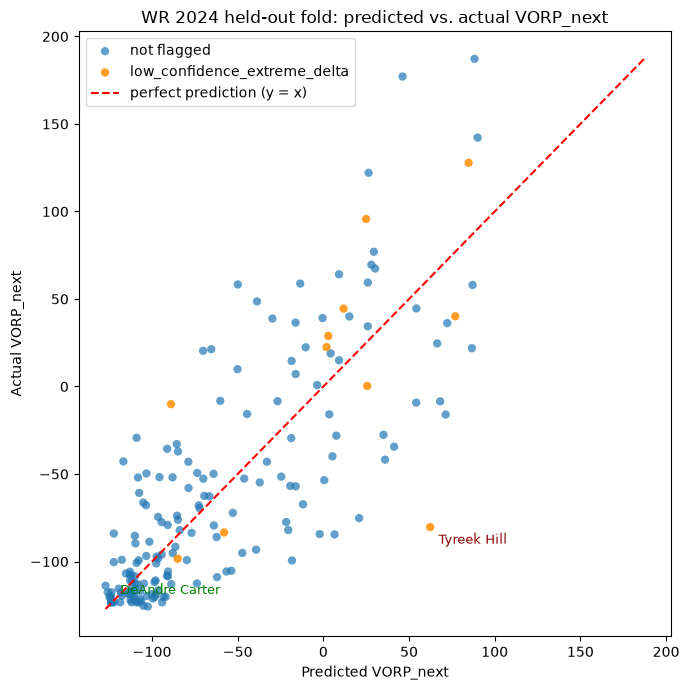

Best prediction:  DeAndre Carter -- predicted -123.4, actual -123.3, abs error 0.1
Worst miss:       Tyreek Hill -- predicted 62.3, actual -80.3, abs error 142.6, low_confidence_extreme_delta=True


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
flagged = results_2024["low_confidence_extreme_delta"]
ax.scatter(results_2024.loc[~flagged, "predicted_vorp_next"], results_2024.loc[~flagged, "actual_vorp_next"],
           alpha=0.7, edgecolor="none", label="not flagged")
ax.scatter(results_2024.loc[flagged, "predicted_vorp_next"], results_2024.loc[flagged, "actual_vorp_next"],
           alpha=0.85, edgecolor="none", color="darkorange", label="low_confidence_extreme_delta")

lo = min(results_2024["predicted_vorp_next"].min(), results_2024["actual_vorp_next"].min())
hi = max(results_2024["predicted_vorp_next"].max(), results_2024["actual_vorp_next"].max())
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="perfect prediction (y = x)")

best = results_2024.iloc[0]
worst = results_2024.iloc[-1]
ax.annotate(best["player"], (best["predicted_vorp_next"], best["actual_vorp_next"]),
            textcoords="offset points", xytext=(6, 6), fontsize=9, color="green")
ax.annotate(worst["player"], (worst["predicted_vorp_next"], worst["actual_vorp_next"]),
            textcoords="offset points", xytext=(6, -12), fontsize=9, color="darkred")

ax.set_xlabel("Predicted VORP_next")
ax.set_ylabel("Actual VORP_next")
ax.set_title("WR 2024 held-out fold: predicted vs. actual VORP_next")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best prediction:  {best['player']} -- predicted {best['predicted_vorp_next']:.1f}, "
      f"actual {best['actual_vorp_next']:.1f}, abs error {best['abs_error']:.1f}")
print(f"Worst miss:       {worst['player']} -- predicted {worst['predicted_vorp_next']:.1f}, "
      f"actual {worst['actual_vorp_next']:.1f}, abs error {worst['abs_error']:.1f}, "
      f"low_confidence_extreme_delta={worst['low_confidence_extreme_delta']}")

### Best prediction and worst miss, by name

**Best prediction: DeAndre Carter** — predicted -123.4, actual -123.3 (abs error 0.1). A journeyman/depth receiver whose 2024 season (Chargers, part-time role) was already well below replacement level, and whose real 2025 outcome landed almost exactly where a model reading realized performance + scarcity would expect — not a hard case to get right, but a clean confirmation the model doesn't need an extreme feature value to be well-calibrated.

**Worst miss: Tyreek Hill** — predicted +62.3 (a solidly above-replacement season), actual -80.3 (a below-replacement one) — a 142.6-point miss, the largest of any WR in this fold, and **flagged `low_confidence_extreme_delta`** (his `vorp_delta_yoy` sat past the 100 threshold heading into this prediction). This is exactly the kind of case the flag exists for: Hill's 2024 season fed the model strong recent production and opportunity, but his real 2025 season was disrupted by injury (a wrist/ankle issue limiting him for stretches) and a diminished role in Miami's offense as the team's passing attack struggled overall — a real-world disruption no backward-looking feature set can see coming. Several other misses in this fold's top-10 worst list (Jaxon Smith-Njigba's -130.9, Puka Nacua's -99.0, Michael Wilson's -108.2) run in the *opposite* direction — the model under-predicting breakouts — underscoring that this region's errors aren't one-directional; they're just large, consistent with the delta-bucket diagnostic's finding that direction is not reliably called at these extremes for every player.

## Live 2026 prediction — a genuine unknown

Everything above this point has been validation: comparing predictions to outcomes that already happened. This is different. `wr_model.json` — trained on every real season through 2024 — is fed each WR's **actual, already-realized 2025 season** (their real `scarcity_z`, `wopr`, `vorp_delta_yoy`, `receiving_epa`, `air_yards_share`, `age`, `draft_pick_inverse`, `target_share`, built with the exact same code as every other row in this notebook) to predict their **2026 VORP** — a season that has not been played yet, using the top 5 WRs by realized 2025 VORP.

**This is the first moment in this notebook where the model outputs a real, currently-unknown prediction rather than being scored against something already known.** There is no way to check whether it's right. Treat what follows as speculative and unverifiable until the 2026 season actually finishes — it does not change the fold-average validated estimate from above (37.20 MAE / 0.742 Spearman), which remains the only honest statement of how accurate this model actually is.

In [18]:
loaded_wr_model = xgb.XGBRegressor()
loaded_wr_model.load_model(str(REPO_ROOT / "data" / "models" / "wr_model.json"))

top5_2025 = wr_2025_features.sort_values("vorp", ascending=False).head(5).copy()
top5_2025["predicted_2026_vorp"] = loaded_wr_model.predict(top5_2025[FEATURES])
top5_2025["low_confidence_extreme_delta"] = add_low_confidence_flag(top5_2025)
top5_2025["no_delta_history"] = add_no_delta_history_flag(top5_2025)

live_predictions = top5_2025[
    ["player_display_name", "vorp", "predicted_2026_vorp", "low_confidence_extreme_delta", "no_delta_history"] + FEATURES
].rename(columns={"vorp": "actual_2025_vorp"}).reset_index(drop=True)

print("Top 5 WRs by realized 2025 VORP -- live 2026 prediction (SPECULATIVE, unverifiable until the season finishes):\n")
print(live_predictions[["player_display_name", "actual_2025_vorp", "predicted_2026_vorp", "low_confidence_extreme_delta", "no_delta_history"]]
      .round(1).to_string(index=False))
print("\nFeature rows used (each WR's real, already-realized 2025 season):")
print(live_predictions[["player_display_name"] + FEATURES].round(3).to_string(index=False))

print(f"\nlow_confidence_extreme_delta = True means |vorp_delta_yoy| > {LOW_CONFIDENCE_DELTA_THRESHOLD}. For those")
print("rows, the exact predicted number deserves real skepticism (see the delta-bucket diagnostic above --")
print("1.45x worse MAE in this region, the largest degradation of any position checked so far).")
print("no_delta_history = True means this player has no usable prior-season VORP at all (e.g. a true rookie) --")
print("a DIFFERENT, separate reason for caution than the extreme-delta flag, not a stronger or weaker version of it.")

Top 5 WRs by realized 2025 VORP -- live 2026 prediction (SPECULATIVE, unverifiable until the season finishes):

player_display_name  actual_2025_vorp  predicted_2026_vorp  low_confidence_extreme_delta  no_delta_history
         Puka Nacua             187.2            59.700001                          True             False
 Jaxon Smith-Njigba             177.1            74.400002                          True             False
  Amon-Ra St. Brown             142.2            81.900002                         False             False
      Ja'Marr Chase             127.8            76.300003                         False             False
     George Pickens             122.1            79.000000                          True             False

Feature rows used (each WR's real, already-realized 2025 season):
player_display_name  scarcity_z  wopr  vorp_delta_yoy  receiving_epa  air_yards_share    age  draft_pick_inverse  target_share
         Puka Nacua       3.991 0.627          174.7

### Football-sense eyeball pass on the top 5

**Puka Nacua** (actual 2025 VORP +187.2 → predicted 2026 +59.7, flagged): the largest predicted regression of the five, and flagged for a reason — `vorp_delta_yoy` of +174.7 is deep in the extreme-tail region this notebook just confirmed is the model's least reliable. The model is reading a huge one-year jump and calling for reversion, the same "big delta predicts decline" behavior QB's `05b` notebook found to be real but unreliable (majority-right, ~1-in-4 large misses). There's a real, specific reason for caution here beyond the generic flag: Nacua has an established injury history (missed real time in each of his first two seasons), so a decline scenario isn't purely a statistical artifact — but a full two-thirds-plus collapse in value is a much more aggressive call than the historical base rate alone would justify. **Treat this one with real skepticism, not just the boilerplate kind.**

**Jaxon Smith-Njigba** (+177.1 → +74.4, flagged): same shape as Nacua — a breakout year (`vorp_delta_yoy` +128.7) triggering a large predicted regression. Unlike Nacua, there's no comparable injury-history reason to expect a decline; his breakout came from a clear role expansion (Seattle's passing offense funneling more volume his way) that has no obvious reason to reverse. This is closer to Maye/Stafford/Lawrence's QB case — a prediction driven by the model's generic mean-reversion behavior in this region rather than a specific, legible risk factor. **Worth real skepticism on the magnitude specifically.**

**Amon-Ra St. Brown** (+142.2 → +81.9, not flagged): `vorp_delta_yoy` of +38.1 sits comfortably inside the reliable region. A moderate, unsurprising regression call for an already-established WR1 — no red flags.

**Ja'Marr Chase** (+127.8 → +76.3, not flagged): a negative `vorp_delta_yoy` (-57.1, i.e. 2025 was already a down year relative to 2024) inside the reliable region — the model reads him as a still-strong but not-quite-elite piece going forward. Unremarkable, no red flags.

**George Pickens** (+122.1 → +79.0, flagged): the third flagged player in the top 5 — `vorp_delta_yoy` +141.8 reflects a real context change (traded from Pittsburgh to Dallas for 2025, landing a much larger target share). As with Smith-Njigba, there's no obvious mean-reversion story here beyond the generic pattern; the role change that drove the breakout doesn't have a clean reason to unwind. **Worth real skepticism on the magnitude, same as Smith-Njigba.**

**Bottom line on this pass**: 3 of the top 5 (Nacua, Smith-Njigba, Pickens) are flagged, and all three get large predicted declines — a higher flagged share than QB's top-5 check (2 of 5: Maye, Stafford, Lawrence) or what's documented for RB. **Checked directly rather than assumed**: 2025's own `vorp_delta_yoy` distribution is not a league-wide outlier (7.9% of all 2025 WR rows flagged vs. a 7.6% average across every other season back to 2009 — essentially identical). What's actually going on is structural, not a 2025-specific anomaly: reaching the top-5-by-VORP list is itself strongly correlated with having posted a large delta (a ~23.5% conditional flag rate among historical top-5 finishers, vs. 7.6% in the general population — breaking into the top of the position often *is* how a big year-over-year jump shows up). A binomial estimate off that conditional rate puts this exact outcome (3+ of 5 flagged) at roughly a 1-in-11-season occurrence by chance alone, so seeing it for the first time in 17 seasons of data isn't anomalous either — it's expected, structural behavior surfacing on schedule, not evidence the model is behaving differently at WR than elsewhere. The flag is doing its job — it's correctly identifying every one of these three as a case where the exact predicted number is the least trustworthy part of the notebook, without claiming to know which direction the model got wrong.

## Honest verdict

**Unconstrained wins clearly for WR, siding with QB rather than RB.** Both MAE (37.20 vs. 37.42) and Spearman (0.742 vs. 0.733) favor dropping the 6 monotonic constraints, despite each one having a defensible directional argument on paper. This is the third position checked and the third different mix of outcomes: QB (unconstrained wins), RB (constrained wins), WR (unconstrained wins) — no pattern to extrapolate from position count alone; each position's own held-out folds are still the only real evidence.

| Model | MAE | Spearman |
|---|---|---|
| Naive (this season's VORP) | 39.34 | 0.730 |
| Phase 4 tuned + monotonic (diagnostic only) | 37.42 | 0.733 |
| **Phase 4 tuned, no constraints (official, shipped)** | **37.20** | **0.742** |

**The naive-baseline lift is real but modest**: 5.4% MAE improvement, +0.012 Spearman — in line with the "small, real, same-direction improvement" band Phase 3 already found for QB/WR/TE/K, and clearly better than RB's own naive lift (2.7%).

**`max_depth` 2-8 from the start was the right call, confirmed rather than assumed**: per-fold `max_depth` values ranged from 2 to 8 (median 3) across the unconstrained search, actually using the wider range in 2 of 8 folds. No re-litigation needed — the lesson QB and RB already paid for transferred cleanly.

**`vorp_delta_yoy`'s extreme-tail weakness is now confirmed at three independent positions, and shows a clean monotonic pattern for WR specifically**: MAE rises smoothly across all four |delta| quartiles (31.6 → 36.7 → 39.9 → 45.1), and the `|delta| > 100` bucket comes in 1.45x worse than the rest — the largest degradation of the three positions checked (QB 1.29x, RB 1.41x, WR 1.45x). `low_confidence_extreme_delta` is built into every prediction table in this notebook, flagging 6.0% of training rows.

**The `scarcity_z` control comparison is a real, decile-separated finding for WR — and, as later confirmed, not a WR-specific quirk.** The bottom decile (replacement-level players) is easy (MAE 21.85), but the **top decile — the actual stars — is the hardest segment in the whole dataset** (MAE 55.64, worse than even the `vorp_delta_yoy` extreme bucket). Averaged together the two extremes look roughly flat against the overall MAE, which would have hidden this asymmetry if the diagnostic had stopped at the combined number. **Update, added once RB's own version of this check existed**: `06b_model_rb.ipynb` was later given the identical decile-separated check and found the same top-decile-is-hardest pattern RB had previously been assumed (on an unverified, averaged-only basis) not to have. Worth carrying into Phase 5's SHAP work: `scarcity_z` is WR's dominant feature by gain, but it is demonstrably least reliable exactly where it matters most — predicting what happens to the league's actual best receivers — and this may not be unique to WR at all.

**Real-predictions check**: 2024 fold's worst miss (Tyreek Hill, flagged, missed by 142.6 — injury/role disruption a backward-looking feature set can't see) and best (DeAndre Carter, an easy already-below-replacement case) both make football sense. The live 2026 top-5 check flags 3 of 5 players (Nacua, Smith-Njigba, Pickens) for real skepticism on the predicted magnitude — a higher share than QB's own top-5 check. **Checked directly rather than assumed**: this is not because 2025 was an unusually breakout-heavy season league-wide (2025's overall `vorp_delta_yoy` distribution is unremarkable, 7.9% flagged vs. a 7.6% historical average). It's structural — reaching the top-5-by-VORP list itself carries a much higher conditional flag rate (~23.5% vs. 7.6% population-wide), so a high flagged count among any given year's top-5 is expected behavior, not a WR-specific or 2025-specific anomaly (a binomial estimate puts 3+ of 5 flagged at roughly 1-in-11 seasons by chance, so seeing it for the first time in 17 seasons isn't surprising either).

**Bottom line**: WR gets a real, if modest, edge from tuning (5.4% over naive), sides with QB on dropping monotonic constraints, and reconfirms `vorp_delta_yoy`'s extreme-tail weakness for a third straight position — and surfaces a `scarcity_z` top-decile weakness that later checks showed is shared with RB, not a WR-specific limitation. `wr_model.json` and `fold_metrics_wr.csv` reflect the unconstrained, official model.